**<center> <font size=8> AI-driven Sentiment Analysis for Stock Market News </center>**

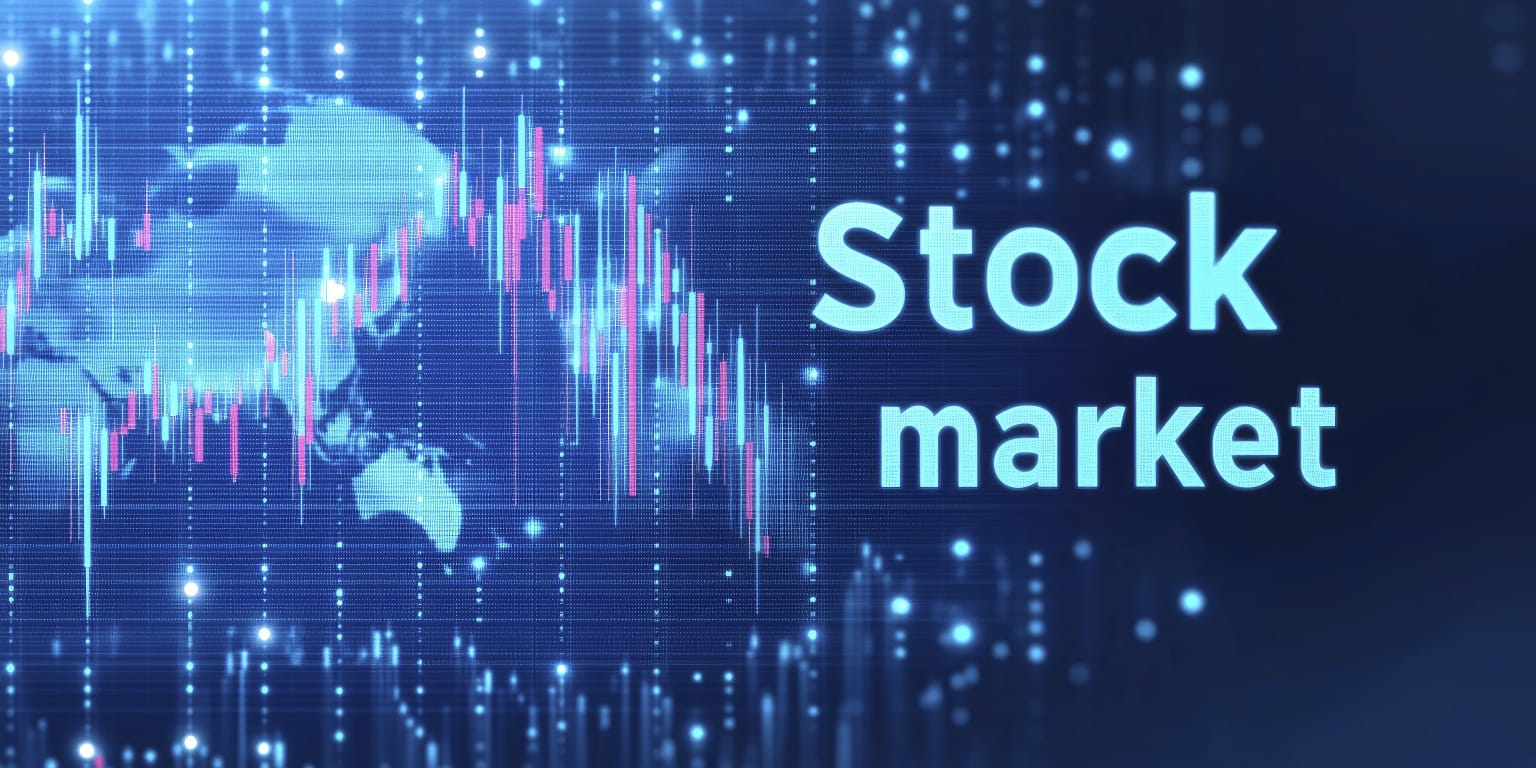

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

* These libraries facilitate data manipulation (numpy, pandas), visualization (matplotlib, seaborn), and various NLP tasks.
They also provide tools for word embeddings (gensim, sentence-transformers) and machine learning models (sklearn, tensorflow, keras).

## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GenAIDataset/stock_news.csv")

In [5]:
# creating a copy of the data
data = News.copy()

* The dataset is initially loaded into a pandas DataFrame named `News`.
* A copy of this `News` DataFrame is then created and assigned to a new DataFrame called `data`.

## **Data Overview**

###**Checking the first 5 rows**

In [6]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


*  `data.head()` displays the first 5 rows, giving a quick look at the DataFrame's structure.
*  It shows two key columns: `Title` (for news headlines) and `Article` (containing the full news text).
*  This view confirms the data's readiness for further sentiment analysis, focusing on text content.

###**Checking the last 5 rows**

In [7]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


* `data.tail()` displays the last 5 rows of the DataFrame, providing insight into the most recent data entries.


###**Checking the shape of the data**

In [8]:
data.shape

(349, 8)

The output `(349, 8)` indicates:
*  **349 rows**: There are 349 news articles or data entries in the dataset.
*  **8 columns**: Each entry has 8 different attributes, such as Date, News content, stock prices (Open, High, Low, Close), Volume, and Sentiment Label.

###**Checking for missing values**

In [9]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


* The output shows that all columns have `0` missing values.
* This indicates a clean dataset with no missing entries, which is ideal for direct use in analysis and model building.

### **Checking for duplicate values**

In [10]:
# checking for duplicate values
data.duplicated().sum()
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


* The output `Number of duplicate rows: 0` indicates that there are no duplicate rows in the dataset.
* This is a positive finding, as it means the data is clean and does not contain redundant entries, ensuring each record is unique and valuable for analysis.

## **Exploratory Data Analysis**

In [11]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [12]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [13]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


*   The output confirms the 'Date' column has been successfully converted to `datetime64[ns]`, which is crucial for time-series analysis.
*   The dataset retains its original dimensions of 349 entries and 8 columns, indicating that no data was altered or lost during the type conversion.

In [14]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

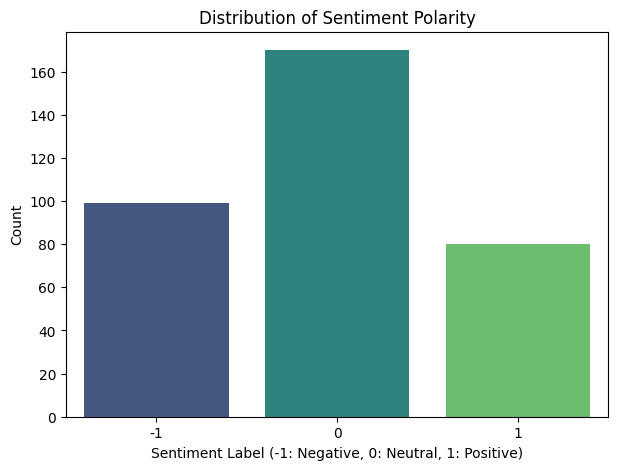

In [15]:
# Distribution of sentiment polarity
plt.figure(figsize=(7, 5))
sns.countplot(x='Label', data=data, palette='viridis')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.show()

*   The sentiment polarity distribution reveals a higher frequency of neutral (0) news articles, followed by negative (-1) and then positive (1) ones, indicating a skew towards neutral or negative sentiment in the dataset.

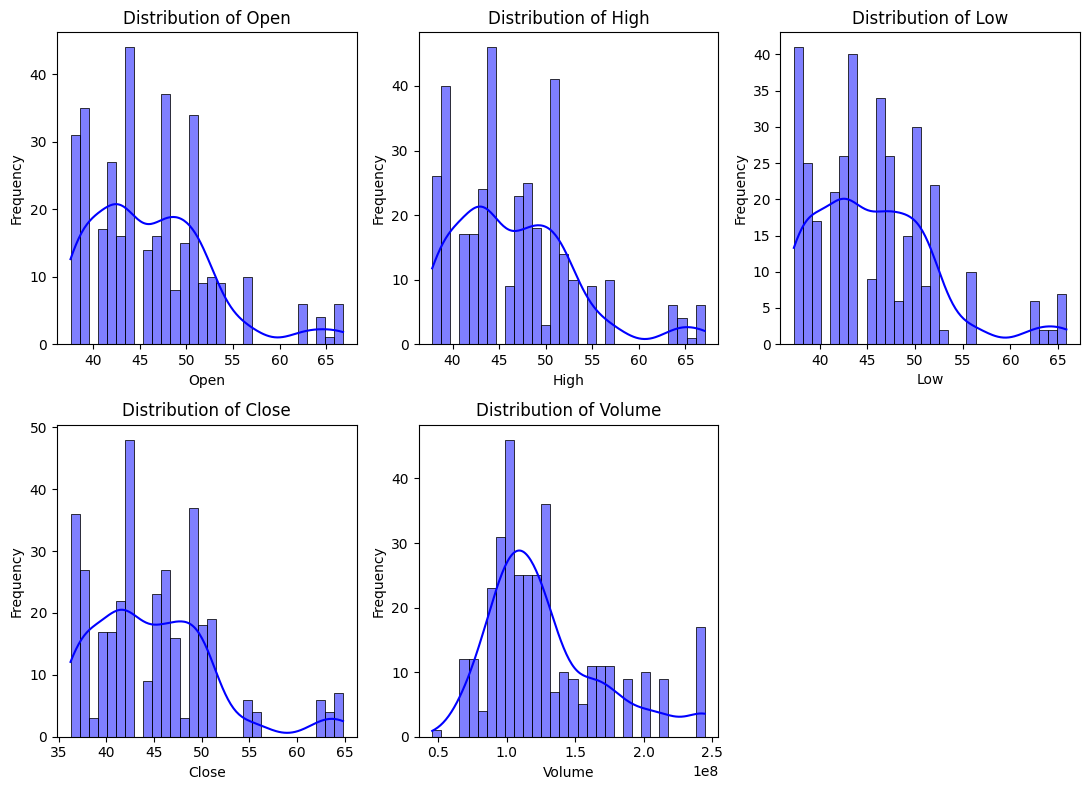

In [16]:
# Plot Distribution of all Numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(11, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.histplot(data[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


*   The distributions of 'Open', 'High', 'Low', and 'Close' prices show multiple peaks, suggesting the stock might have traded within distinct price ranges or experienced different market regimes during the recorded period.
*   Similarly, the 'Volume' distribution also appears to be multimodal, indicating periods of varying trading activity and liquidity.

### **Distribution of the length of news content**

In [17]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(x.split()))

# Summary statistics of news length
display(data['News_Length'].describe())

,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


*   The average news article length is approximately 48 words, with a standard deviation of about 5 words, indicating a relatively consistent article length.
*   The minimum length is 19 words and the maximum is 63 words, showing a narrow range of news content lengths in the dataset.

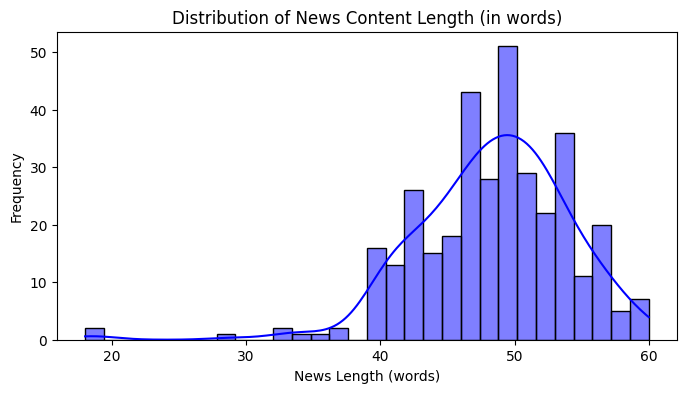

In [18]:
# Plot distribution
plt.figure(figsize=(8, 4))
sns.histplot(data['News_Length'], kde=True, bins=30, color='blue')
plt.title('Distribution of News Content Length (in words)')
plt.xlabel('News Length (words)')
plt.ylabel('Frequency')
plt.show()

*   The majority of news articles have lengths concentrated between approximately 40 and 60 words, indicating a fairly consistent article length within the dataset.
*   The distribution is roughly bell-shaped but shows a slight skew to the left, with some articles being notably shorter than the average.

### **Monthwise Analysis**

In [19]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


*   The average 'High', 'Low', 'Open', and 'Close' stock prices generally show an increasing trend from January to April 2019, indicating a positive market sentiment or growth over these months.
*   The average 'Volume' fluctuates, with a decrease from January to February, followed by a significant increase in March, and then another decrease in April, suggesting varying levels of trading activity throughout the period.

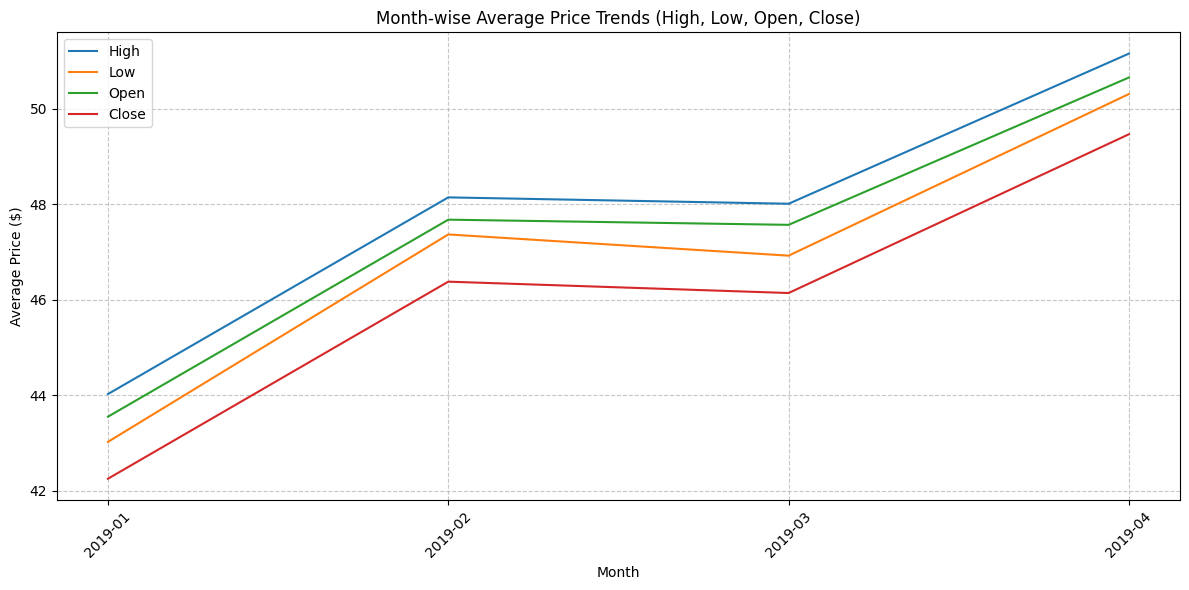

In [20]:
# plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(12, 6))
# Plotting each price variable trend
sns.lineplot(x='YearMonth', y='High', data=monthwise_avg, label='High')
sns.lineplot(x='YearMonth', y='Low', data=monthwise_avg, label='Low')
sns.lineplot(x='YearMonth', y='Open', data=monthwise_avg, label='Open')
sns.lineplot(x='YearMonth', y='Close', data=monthwise_avg, label='Close')

plt.title('Month-wise Average Price Trends (High, Low, Open, Close)')
plt.xlabel('Month')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

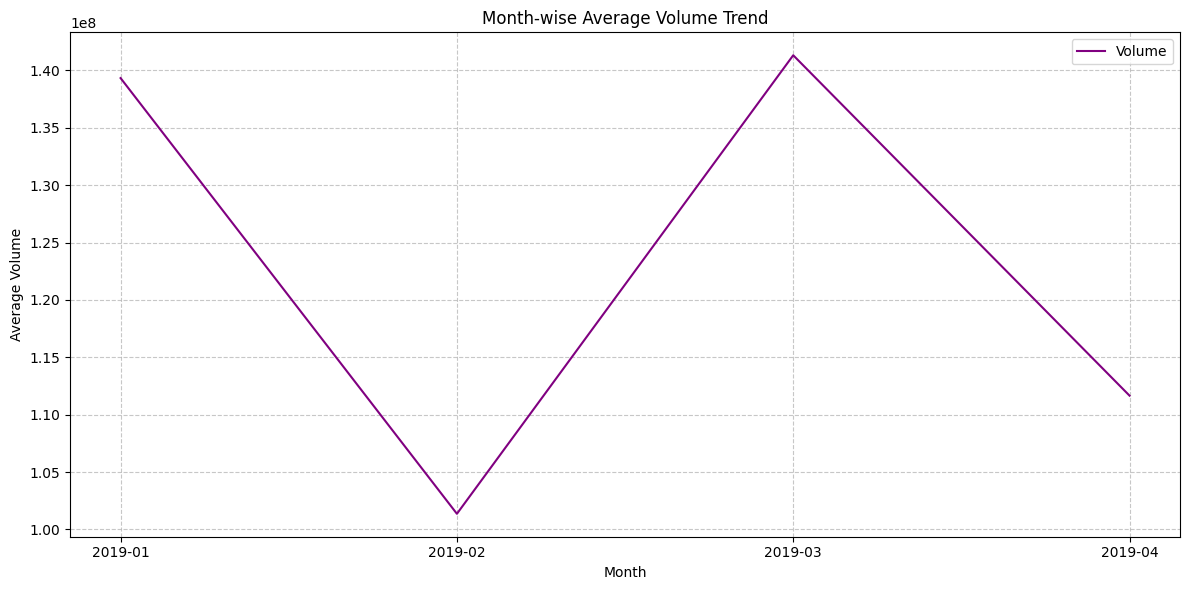

In [21]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='Volume', data=monthwise_avg, label='Volume', color='purple')
plt.title('Month-wise Average Volume Trend')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*   The average trading volume shows notable fluctuations, starting high in January, dropping significantly in February, and then peaking in March before decreasing again in April.
*   This indicates periods of varying investor activity and market interest across the observed months, with March experiencing the highest average trading volume.

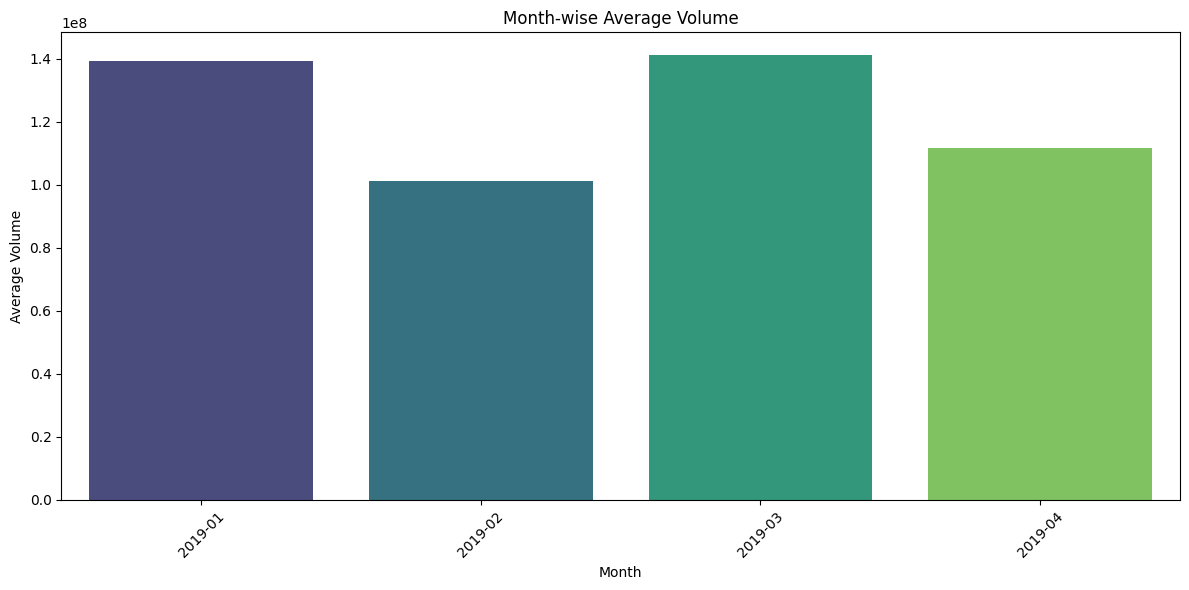

In [22]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='viridis')
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*   The bar plot clearly visualizes the fluctuating average trading volume, highlighting a significant drop in February and a peak in March, suggesting variable investor engagement across these months.

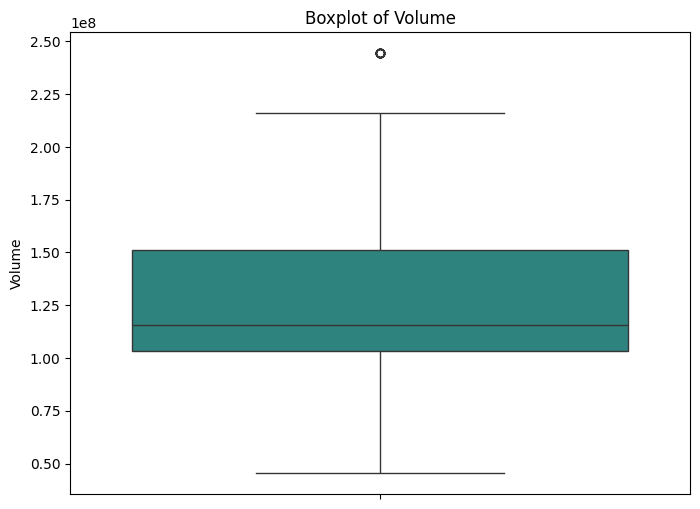

In [23]:
# Boxplot to identify outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['Volume'], palette='viridis')
plt.title('Boxplot of Volume')
plt.ylabel('Volume')
plt.show()

*   The boxplot for 'Volume' indicates the presence of a few outlier data points, specifically on the upper end, suggesting certain days experienced unusually high trading volumes compared to the majority.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

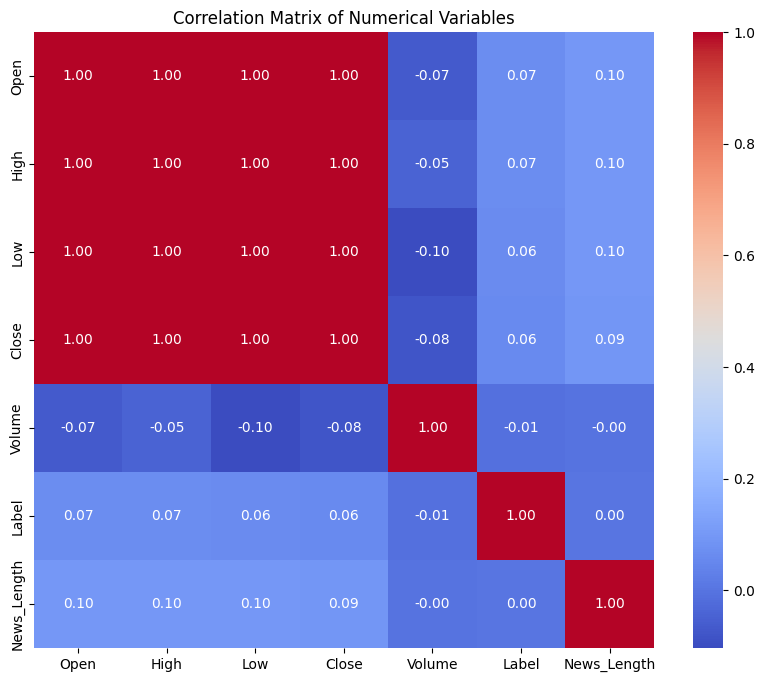

In [24]:
# Correlation matrix to check if variables move together or have correlations
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

*   The heatmap shows a very strong positive correlation (1.00) among 'Open', 'High', 'Low', and 'Close' prices, which is expected as these values typically move together within a single trading day.
*   'Volume' and 'Label' (sentiment polarity) show very weak correlations with each other and with the price variables, suggesting that raw trading volume and the provided sentiment label might not directly or linearly influence daily stock prices in this dataset.

### **Sentiment Polarity vs Price**

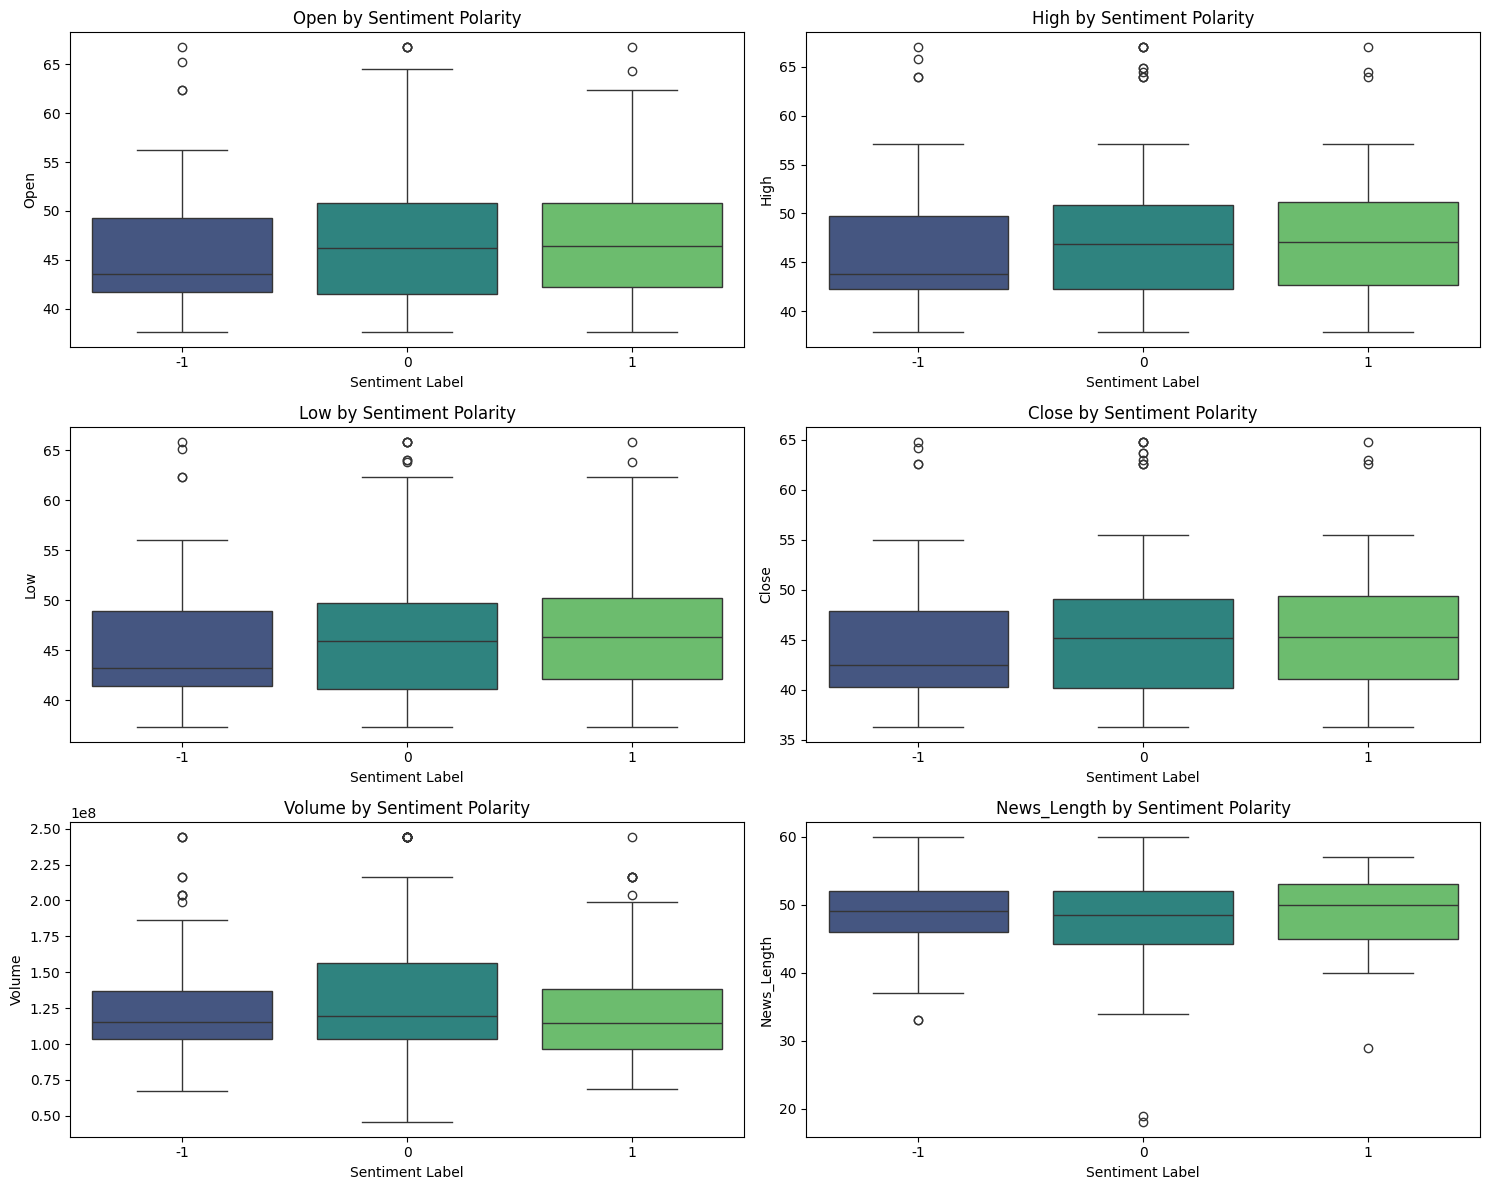

In [25]:
#Sentiment Polarity with all numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='Label', y=col, data=data, palette='viridis')
    plt.title(f'{col} by Sentiment Polarity')
    plt.xlabel('Sentiment Label')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

*   The boxplots for 'Open', 'High', 'Low', and 'Close' prices show similar distributions across all sentiment polarities (-1, 0, 1), suggesting that sentiment alone might not be a strong differentiator of daily stock price ranges.
*   Similarly, 'Volume' and 'News_Length' distributions also appear consistent across sentiment categories, indicating no clear visual relationship between the sentiment of news articles and trading volume or news length.

### **Time Series Analysis (Date vs Price)**

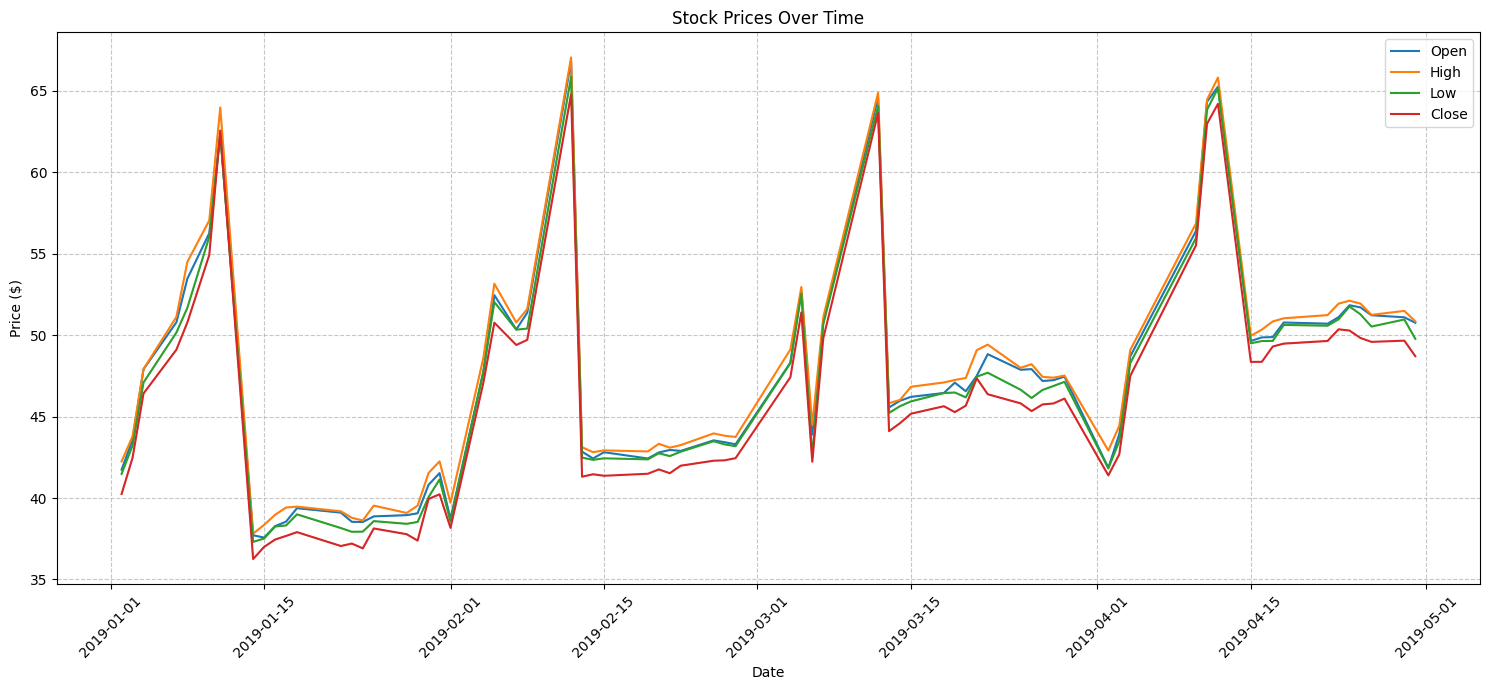

In [26]:
# Time Series Analysis (Date vs Price columns)
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Open', data=data, label='Open')
sns.lineplot(x='Date', y='High', data=data, label='High')
sns.lineplot(x='Date', y='Low', data=data, label='Low')
sns.lineplot(x='Date', y='Close', data=data, label='Close')

plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*   The plot shows a general upward trend in 'Open', 'High', 'Low', and 'Close' stock prices over the observed period, indicating overall market growth or positive sentiment for the company, despite some daily fluctuations.

### **Distribution of News Length Across Sentiment Categories**

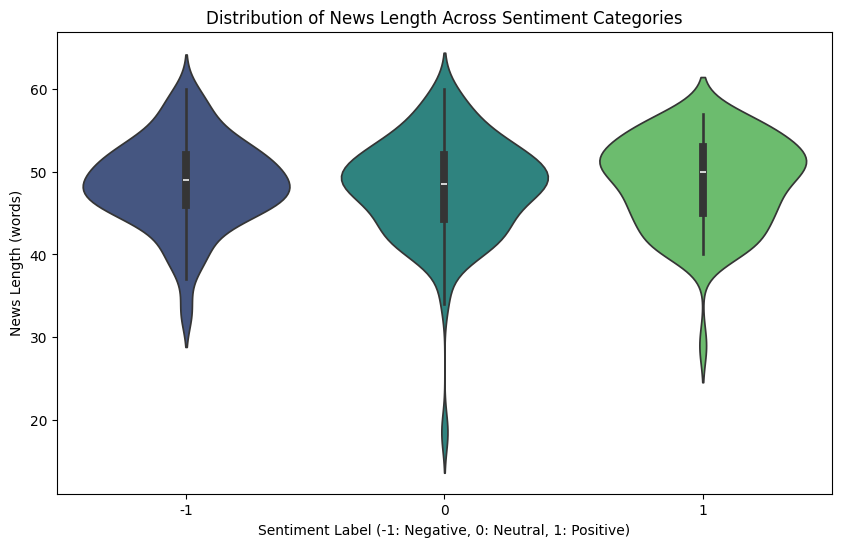

In [27]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Label', y='News_Length', data=data, palette='viridis')
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('News Length (words)')
plt.show()

*   The violin plots indicate that the distribution of news article lengths is broadly similar across all sentiment categories (negative, neutral, and positive), with the bulk of articles in each category having comparable lengths.
*   There are no significant differences in the median news length or the overall spread of lengths between sentiment categories, suggesting that the length of a news article does not appear to be a strong indicator of its sentiment polarity.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [28]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

First, we need to ensure all required libraries are imported and the `average_vectorizer_Word2Vec` function is defined before it's used. `gensim.models.Word2Vec` and `numpy` are already imported in cell `U3bnkPu_ZGbE`.

In [29]:
# Define the average_vectorizer_Word2Vec function
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    # Make sure 'word_vector_dict' is accessible (defined globally or passed)
    words_in_vocab = [word for word in doc.split() if word in word_vector_dict]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

* Now, we will tokenize the news articles and create a list of all words. This list will be used to train our Word2Vec model. We define `vec_size` which will be used in the Word2Vec model and the `average_vectorizer_Word2Vec` function.

In [30]:
# Creating a list of all words in our data
tokenized_news = data['News'].apply(lambda x: x.split())
all_words = [word for sublist in tokenized_news for word in sublist]

print(f"Total number of words: {len(all_words)}")

vec_size = 100 # Define the vector size for Word2Vec embeddings

Total number of words: 16874


* Next, we will train a Word2Vec model using the `gensim` library. This model will learn vector representations for each word in our vocabulary.

In [31]:
# Training the Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_news, vector_size=vec_size, window=5, min_count=1, workers=4)

print(f"Word2Vec model trained with vector size: {vec_size}")
print(f"Vocabulary size: {len(word2vec_model.wv)}")

Word2Vec model trained with vector size: 100
Vocabulary size: 4681


* Then, we extract the word vectors from the trained Word2Vec model and store them in a dictionary for easy lookup. This dictionary is crucial for the `average_vectorizer_Word2Vec` function.

In [32]:
# Retrieving word vectors for all the words present in the model's vocabulary
words = list(word2vec_model.wv.index_to_key)

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {word: word2vec_model.wv[word] for word in words}

print(f"Number of words with vectors: {len(word_vector_dict)}")

Number of words with vectors: 4681


* Finally, we will use the `average_vectorizer_Word2Vec` function to create a single vector representation for each news article by averaging the Word2Vec embeddings of its constituent words. This will form our feature matrix `X` for subsequent machine learning models.

In [33]:
# Creating a feature matrix X of the vectorized documents
X = np.array([average_vectorizer_Word2Vec(news) for news in data['News']])

print(f"Shape of Word2Vec embeddings (X): {X.shape}")

Shape of Word2Vec embeddings (X): (349, 100)


*   The output `(349, 100)` for the shape of `X` indicates that there are 349 news articles, and each article has been transformed into a numerical vector of 100 dimensions using Word2Vec embeddings.

In [34]:
# Converting the Word2Vec embeddings (X) into a DataFrame
X_df = pd.DataFrame(X)

# Displaying the first 5 rows of the new DataFrame
display(X_df.head())

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.069985,0.087912,0.009468,0.002055,0.011215,-0.119026,0.030893,0.161822,-0.067391,-0.053117,...,0.078787,0.009936,0.033282,0.011390,0.133113,0.067727,0.048302,-0.047612,-0.002972,0.001552
1,-0.065499,0.085920,0.009869,0.001883,0.011677,-0.114647,0.028104,0.156737,-0.067071,-0.050968,...,0.076221,0.009026,0.031445,0.009715,0.128109,0.066547,0.046546,-0.047116,-0.001290,0.000357
2,-0.062262,0.082138,0.009304,0.002076,0.011984,-0.107574,0.027206,0.148618,-0.061966,-0.048106,...,0.071625,0.008518,0.029942,0.008812,0.121052,0.063266,0.044517,-0.043677,-0.001307,0.001016
3,-0.071873,0.091163,0.009214,0.002646,0.011302,-0.120988,0.031280,0.164244,-0.069059,-0.053572,...,0.080378,0.011085,0.033145,0.008741,0.135325,0.070586,0.050899,-0.048798,-0.002690,0.001256
4,-0.070170,0.089821,0.008589,0.002592,0.012887,-0.116727,0.030296,0.162636,-0.068165,-0.051922,...,0.079030,0.008730,0.032583,0.009615,0.133559,0.068060,0.048481,-0.047673,-0.002981,0.001131


*   The output shows the first five rows of the `X_df` DataFrame, where each row represents a news article transformed into a 100-dimensional numerical vector (Word2Vec embedding), demonstrating the numerical representation used as input for the models.

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [35]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

*   This line initializes a `SentenceTransformer` model using the `BAAI/bge-base-en-v1.5` pre-trained model, which is designed to generate high-quality sentence embeddings for English text.

##### Encoding the dataset

In [36]:
embedding_matrix = model.encode(data['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

*   This step processes each news article in the `data['News']` column through the `SentenceTransformer` model to convert them into dense numerical vectors, capturing the semantic meaning of each sentence.

In [37]:
# printing the shape of the embedding matrix
print(f"Shape of the embedding matrix:{embedding_matrix.shape}")

Shape of the embedding matrix:(349, 768)


*   The output `(349, 768)` indicates that the `embedding_matrix` contains 349 entries (corresponding to the news articles), and each news article has been transformed into a dense numerical vector of 768 dimensions by the Sentence Transformer model.

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [38]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

*   This function generates and displays a confusion matrix, which is a table used to evaluate the performance of a classification model.
*   It visually presents the counts of correct and incorrect predictions for each class, making it easy to see where the model is performing well and where it is making errors.

In [39]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

* This function computes and returns key performance metrics (Accuracy, Recall, Precision, and F1-score) for a classification model, based on the actual and predicted labels.

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [40]:
# Storing independent variable
X_word2vec = X

* This line of code assigns the X variable, which contains the Word2Vec embeddings of the news articles, to X_word2vec for use as the independent variable in the Word2Vec-based models.

In [41]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X_word2vec ,y, test_size = 0.2, random_state = 42)

* Before training the model, the dataset is split into training and testing sets. `X` (Word2Vec embeddings) and `y` (sentiment labels) are divided using an 80:20 ratio. `random_state=42` ensures reproducibility of the split, meaning the same data points will be in the training and testing sets each time this code is executed. This separation is crucial for evaluating the model's performance on unseen data.

In [42]:
# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

* A `RandomForestClassifier` model is initialized with `random_state=42` for reproducibility. The model is then trained using the `fit` method on the `X_train` (Word2Vec embeddings of training news articles) and `y_train` (corresponding sentiment labels). This step allows the Random Forest to learn the patterns and relationships between the word embeddings and the sentiment polarities from the training data.

In [43]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)

* Once the Random Forest model is trained, it's used to make predictions on both the training data (`X_train`) and the unseen test data (`X_test`). The `predict` method outputs the predicted sentiment labels for each news article in the respective datasets. These predictions (`y_pred_train`, `y_pred_test`) will then be used to evaluate the model's performance.

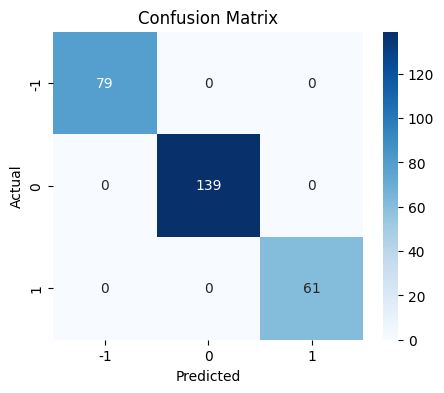

In [44]:
plot_confusion_matrix(y_train, y_pred_train)

* This code block calls the previously defined `plot_confusion_matrix` function to visualize the performance of the Word2Vec Random Forest model on the **training data**. A confusion matrix provides a detailed breakdown of correct and incorrect classifications, showing how many instances of each actual sentiment class were predicted as each sentiment class.

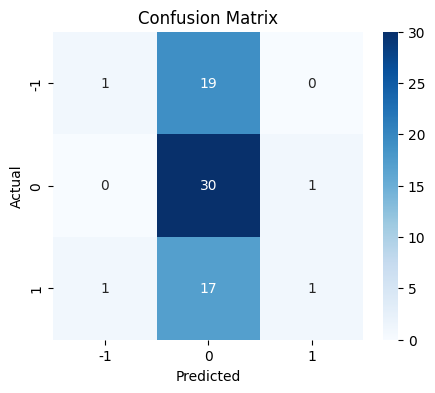

In [45]:
plot_confusion_matrix(y_test, y_pred_test)

* The confusion matrix for the test set reveals that the model struggles to generalize, frequently misclassifying actual negative (-1) and positive (1) sentiments as neutral (0), indicating poor performance on unseen data.

In [46]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.457143 0.457143    0.47987 0.325757


* Here, the `model_performance_classification_sklearn` function is used to calculate key classification metrics (Accuracy, Recall, Precision, F1-score) for the Word2Vec Random Forest model on both the training and test datasets. These metrics provide a quantitative assessment of the model's performance, helping to understand its strengths and weaknesses in classifying sentiment.

###**Sentence Transformer-Random Forest Model**

In [47]:
# Storing independent variable
X = embedding_matrix

* The independent variable `(X)` is stored as the sentence embedding matrix generated by the Sentence Transformer.
These embeddings are used as input features for the Random Forest model to train and predict the target variable.

In [48]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* Similar to the previous model, the data is split into training and testing sets (`X` being the SentenceTransformer BAAI embeddings and `y` being the sentiment labels) using an 80:20 ratio with `random_state=42` for reproducibility. This split is essential for an unbiased evaluation of the model's ability to generalize to new, unseen sentiment data.

In [49]:
# Building the model
rf_model_transformer = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

* A `RandomForestClassifier` is initialized with `random_state=42` and trained (`fit` method) using the `X_train` (SentenceTransformer BAAI embeddings) and `y_train` (corresponding sentiment labels). This step trains the ensemble model to learn patterns from the contextual embeddings, enabling it to classify the sentiment of news articles.

In [50]:
# Predicting on train data
y_pred_train = rf_model_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_model_transformer.predict(X_test)

* [link text](https://)Predictions are generated for both the training and test sets using the trained SentenceTransformer BAAI Random Forest model. These `y_pred_train_transformer_BAAI` and `y_pred_test_transformer_BAAI` predictions represent the model's classification of sentiment based on the input embeddings, and they will be used for subsequent evaluation.

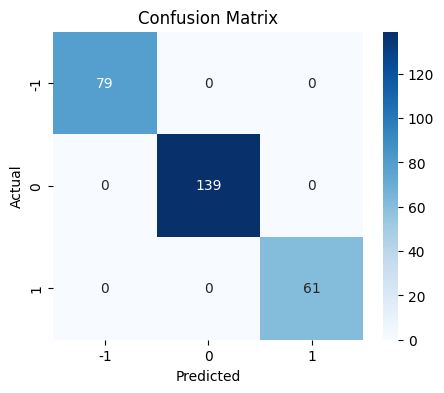

In [51]:
plot_confusion_matrix(y_train, y_pred_train)

* This code block visualizes the performance of the SentenceTransformer BAAI Random Forest model on the **training data** using a confusion matrix. It helps to understand how accurately the model classified the sentiment of the news articles it was trained on.

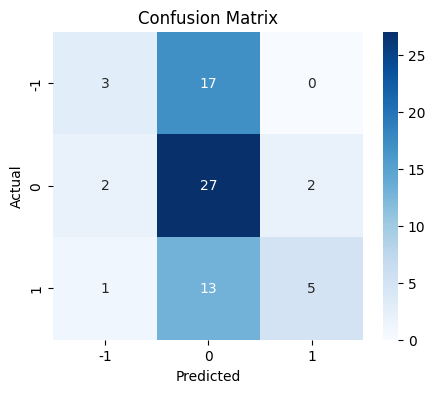

In [52]:
plot_confusion_matrix(y_test, y_pred_test)

* This code block visualizes the performance of the SentenceTransformer BAAI Random Forest model on the **test data** using a confusion matrix. This visualization is crucial for assessing the model's generalization capabilities to new, unseen data.

In [53]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


* The `model_performance_classification_sklearn` function is utilized here to compute and display the accuracy, recall, precision, and F1-score for the SentenceTransformer BAAI Random Forest model on both the training and test sets. These metrics provide a quantitative evaluation of the model's effectiveness in sentiment classification, allowing for comparison with other models.

### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [54]:
# Storing independent variable
X = X_word2vec

* The `X` (containing the Word2Vec feature matrix stored in `X_word2vec`) is explicitly set as the independent variable for the machine learning model. This ensures that the model processes these Word2Vec feature vectors as input to learn meaningful patterns and perform accurate predictions.

In [55]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

* The dataset is split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets using the `train_test_split()` function. This ensures that 80% of the data is used for training and 20% is reserved for testing, while `random_state=42` guarantees a consistent and reproducible data split across multiple executions.

In [56]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

* The sentiment labels are converted from `{-1, 0, 1}` to `{0, 1, 2}` using the `label_map` dictionary. This ensures that the target labels are in a format compatible with the Neural Network model, with the converted labels stored in `y_train_mapped` and `y_test_mapped` for training and evaluation.

In [57]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

* This cell defines and compiles the Neural Network model. It's a sequential model with:  - Two `Dense` (fully connected) layers with 'relu' activation and `Dropout` layers for regularization (to prevent overfitting).  - An output `Dense` layer with 3 neurons (for the three sentiment classes: -1, 0, 1) and 'softmax' activation, which outputs probabilities for each class.  The model is compiled with the 'adam' optimizer and 'sparse_categorical_crossentropy' loss function, suitable for multi-class classification with integer labels.

In [58]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.4409 - loss: 1.0808 - val_accuracy: 0.4429 - val_loss: 1.0775
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0470 - val_accuracy: 0.4429 - val_loss: 1.0777
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0403 - val_accuracy: 0.4429 - val_loss: 1.0877
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0452 - val_accuracy: 0.4429 - val_loss: 1.0868
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0450 - val_accuracy: 0.4429 - val_loss: 1.0871
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0292 - val_accuracy: 0.4429 - val_loss: 1.0859
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0406 - val_accuracy: 0.4429 - val_loss: 1.0825
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0434 - val_accuracy: 0.4429 - val_loss: 1.0837


* The Neural Network model is trained using the `fit` method on the `X_train` (Word2Vec embeddings) and `y_train_mapped` (mapped sentiment labels). Validation data (`X_test`, `y_test_mapped`) is provided to monitor the model's performance on unseen data during training over 20 epochs with a batch size of 32. This process allows the model to learn and adjust its internal weights to minimize the loss and improve accuracy.

In [59]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)
# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


* After training, the Neural Network model predicts the class probabilities for the training data (`X_train`). `np.argmax` is then applied to these probabilities to convert them into discrete class labels (0, 1, or 2), representing the model's predicted sentiment for each training news article. These `y_train_preds_Word2Vec_NN` will be used for evaluating training performance.

In [60]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)
# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


* The trained Neural Network model predicts class probabilities for the unseen test data (`X_test`). Similar to the training predictions, `np.argmax` converts these probabilities into discrete class labels (0, 1, or 2), forming `y_test_preds_Word2Vec_NN`. These predictions are crucial for assessing the model's generalization ability to new data.

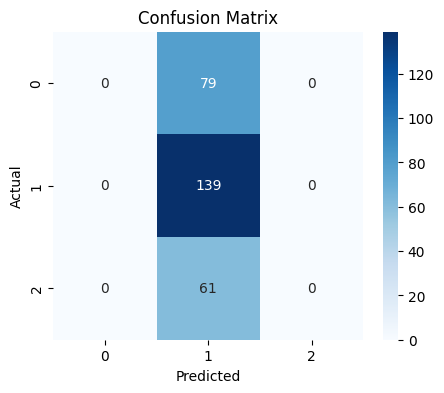

In [61]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

* This code block utilizes the `plot_confusion_matrix` function to visualize the performance of the Word2Vec Neural Network model on the **training data**. It provides a clear picture of how well the model classified sentiments for the data it was trained on.

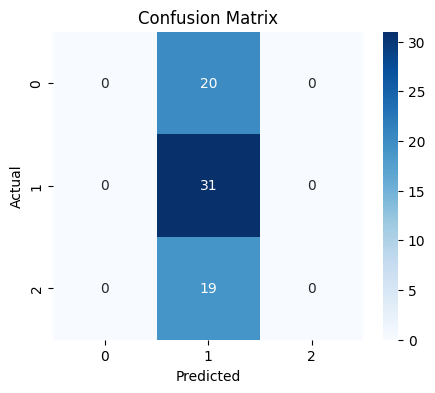

In [62]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

* This code block visualizes the performance of the Word2Vec Neural Network model on the **test data** using a confusion matrix. This is essential to understand the model's real-world applicability and its ability to generalize to new, unseen sentiment data.

In [63]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


* The `model_performance_classification_sklearn` function is called to compute the accuracy, recall, precision, and F1-score for the Word2Vec Neural Network model on both the mapped training and test datasets. These quantitative metrics allow for a comprehensive evaluation of the model's performance and facilitate comparison with other models.

### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [64]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* The dataset is split into training and testing sets (80:20 ratio, `random_state=42`) using `X` (which should now contain the SentenceTransformer `all-MiniLM-L6-v2` embeddings, as set in a previous cell) and `y` (sentiment labels). This ensures a robust evaluation of the Neural Network's generalization performance on unseen sentiment data.

In [65]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

* The sentiment labels in `y_train` and `y_test` (which are -1, 0, 1) are remapped to 0, 1, 2, respectively. This transformation is necessary for compatibility with the `sparse_categorical_crossentropy` loss function used in TensorFlow/Keras Neural Networks, which requires integer-encoded target labels starting from zero.

In [66]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

* This cell defines and compiles the Neural Network model. It employs a `Sequential` architecture with two `Dense` hidden layers (using 'relu' activation) and `Dropout` layers for regularization, preventing overfitting. The output layer has 3 neurons with 'softmax' activation to predict probabilities for the three sentiment classes. The model is compiled with the 'adam' optimizer and 'sparse_categorical_crossentropy' loss, appropriate for multi-class classification.

In [67]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4050 - loss: 1.0954 - val_accuracy: 0.4429 - val_loss: 1.0842
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0678 - val_accuracy: 0.4429 - val_loss: 1.0761
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0566 - val_accuracy: 0.4429 - val_loss: 1.0778
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0384 - val_accuracy: 0.4429 - val_loss: 1.0839
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0382 - val_accuracy: 0.4429 - val_loss: 1.0873
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0472 - val_accuracy: 0.4429 - val_loss: 1.0870
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0428 - val_accuracy: 0.4429 - val_loss: 1.0847
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0462 - val_accuracy: 0.4429 - val_loss: 1.0824


* The Neural Network model is trained using the `fit` method on the `X_train` (SentenceTransformer `all-MiniLM-L6-v2` embeddings) and `y_train_mapped` (mapped sentiment labels). The `validation_data` is used to monitor performance on the test set during training. The model is trained for 20 epochs with a batch size of 32, allowing it to learn the complex relationship between the sentence embeddings and sentiment.

In [68]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


* After training, the Neural Network model generates class probabilities for the training data (`X_train`). `np.argmax` is then applied to these probabilities to derive the predicted sentiment class labels (0, 1, or 2), which are stored in `y_train_preds`. These predictions are used to evaluate the model's performance on the data it has learned from.

In [69]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


* The trained Neural Network model predicts class probabilities for the unseen test data (`X_test`). `np.argmax` is used to convert these probabilities into discrete class labels (0, 1, or 2), resulting in `y_test_preds`. These predictions are vital for assessing the model's ability to generalize to new, real-world sentiment analysis tasks.

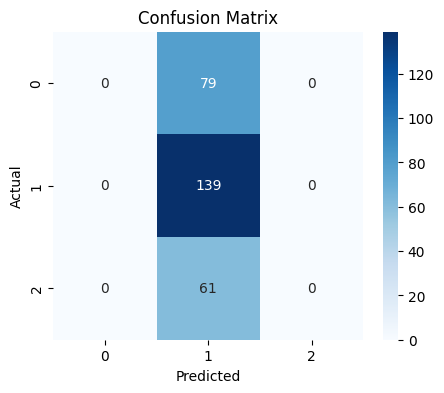

In [70]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

* This code block visualizes the performance of the SentenceTransformer `all-MiniLM-L6-v2` Neural Network model on the **training data** using a confusion matrix. This helps to confirm that the model has effectively learned the patterns in the training data.

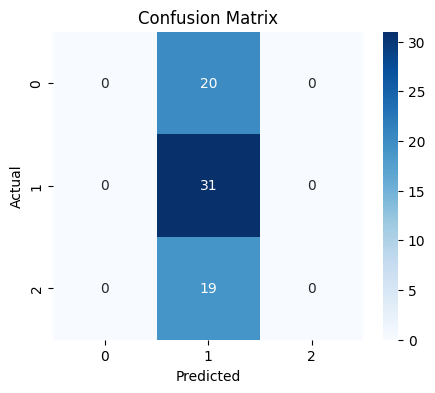

In [71]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

* This code block visualizes the performance of the SentenceTransformer `all-MiniLM-L6-v2` Neural Network model on the **test data** using a confusion matrix. This visualization is crucial for understanding the model's actual performance on unseen data and identifying any potential issues with generalization.

In [72]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


* The `model_performance_classification_sklearn` function is employed here to calculate and display the accuracy, recall, precision, and F1-score for the SentenceTransformer `all-MiniLM-L6-v2` Neural Network model on both the mapped training and test datasets. These metrics provide a comprehensive quantitative assessment, enabling a detailed comparison with other sentiment analysis models developed in this notebook.

### **Generating Embeddings with Sentence Transformers using the all-MiniLM-L6-v2 embedding - Random Forest Model**

In [77]:
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [78]:
# Encode the news articles using the all-MiniLM-L6-v2 SentenceTransformer model
embedding_matrix_minilm = model_minilm.encode(data['News'], show_progress_bar=True)

print(f"Shape of the embedding matrix for all-MiniLM-L6-v2: {embedding_matrix_minilm.shape}")

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Shape of the embedding matrix for all-MiniLM-L6-v2: (349, 384)


The output `(349, 384)` indicates that the `embedding_matrix_minilm` contains 349 entries (corresponding to the news articles), and each news article has been transformed into a dense numerical vector of 384 dimensions by the `all-MiniLM-L6-v2` Sentence Transformer model.

In [79]:
# Storing independent variable
X_minilm = embedding_matrix_minilm

The independent variable `(X_minilm)` is stored as the sentence embedding matrix generated by the `all-MiniLM-L6-v2` Sentence Transformer. These embeddings are used as input features for the Random Forest model to train and predict the target variable.

In [80]:
# Split data into training and testing set.
X_train_minilm, X_test_minilm, y_train, y_test = train_test_split(X_minilm, y, test_size=0.2, random_state=42)

The dataset is split into training and testing sets (`X` being the SentenceTransformer `all-MiniLM-L6-v2` embeddings and `y` being the sentiment labels) using an 80:20 ratio with `random_state=42` for reproducibility. This split is essential for an unbiased evaluation of the model's ability to generalize to new, unseen sentiment data.

In [81]:
# Building the model
rf_model_minilm = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_minilm.fit(X_train_minilm, y_train)

RandomForestClassifier(random_state=42)

A `RandomForestClassifier` is initialized with `random_state=42` and trained (`fit` method) using the `X_train_minilm` (`all-MiniLM-L6-v2` embeddings) and `y_train` (corresponding sentiment labels). This step trains the ensemble model to learn patterns from the contextual embeddings, enabling it to classify the sentiment of news articles.

In [82]:
# Predicting on train data
y_pred_train_minilm = rf_model_minilm.predict(X_train_minilm)

# Predicting on test data
y_pred_test_minilm = rf_model_minilm.predict(X_test_minilm)

Predictions are generated for both the training and test sets using the trained `all-MiniLM-L6-v2` SentenceTransformer Random Forest model. These `y_pred_train_minilm` and `y_pred_test_minilm` predictions represent the model's classification of sentiment based on the input embeddings, and they will be used for subsequent evaluation.

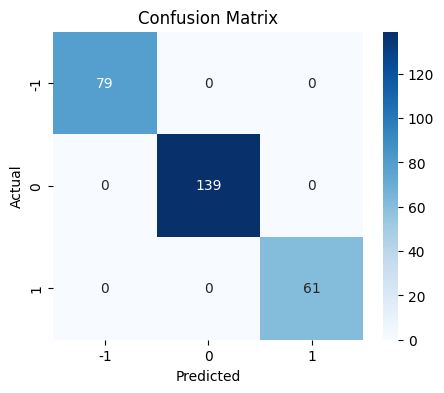

In [83]:
plot_confusion_matrix(y_train, y_pred_train_minilm)

This confusion matrix visualizes the Random Forest model's performance on the training data when using `all-MiniLM-L6-v2` Sentence Transformer embeddings. A strong diagonal indicates good performance on the training set, suggesting the model has learned to classify the sentiment of the news articles it was trained on with high accuracy. This is a check for whether the model was able to fit the training data.

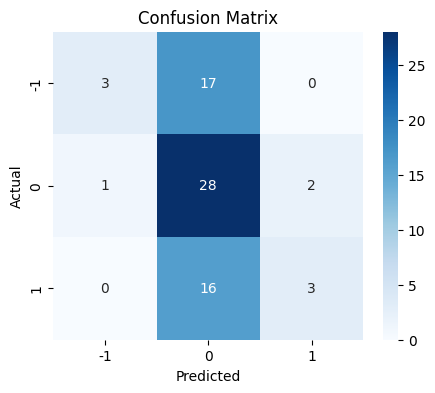

In [84]:
plot_confusion_matrix(y_test, y_pred_test_minilm)

This confusion matrix visualizes the Random Forest model's performance on the test data when using `all-MiniLM-L6-v2` Sentence Transformer embeddings. This is a critical evaluation of the model's generalization ability to unseen news articles. A significant reduction in diagonal values compared to the training set's confusion matrix would indicate overfitting, meaning the model did not generalize well to new data.

In [85]:
train_transformer_minilm_RF = model_performance_classification_sklearn(y_train, y_pred_train_minilm)
print("Training set performance metrics:")
print(train_transformer_minilm_RF.to_string(index=False))
test_transformer_minilm_RF = model_performance_classification_sklearn(y_test, y_pred_test_minilm)
print("Test set performance metrics:")
print(test_transformer_minilm_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


The training set performance metrics for the `all-MiniLM-L6-v2` Random Forest model show perfect scores (Accuracy, Recall, Precision, F1 all at 1.0), indicating the model has completely memorized the training data. However, the test set metrics (Accuracy around 0.486, F1 around 0.409) are significantly lower, once again demonstrating severe overfitting. Despite using different advanced embeddings, the Random Forest model continues to struggle with generalization on this dataset.

### **Generating Embeddings with Sentence Transformers using the all-MiniLM-L6-v2 embedding - Neural Network Model**

This comprehensive cell performs several crucial steps for the all-MiniLM-L6-v2 Sentence Transformer Neural Network model:

**Environment Setup**: Clears previous TensorFlow sessions and collects garbage to ensure a clean slate.
**Data Preparation**: Makes a copy of the News data and defines the target variable y.
**Model Loading**: Loads the all-MiniLM-L6-v2 SentenceTransformer model, which is highly efficient for generating contextualized sentence embeddings.
**Embedding Generation**: Encodes all news articles into embedding_matrix_minilm, converting textual data into numerical vectors.
**Data Splitting**: Splits the embeddings (X) and mapped labels (y) into training and testing sets (80:20 ratio) for model development and evaluation.
**Label Mapping**: Transforms the original sentiment labels (-1, 0, 1) to 0-indexed integers (0, 1, 2) required for the neural network's loss function.
**Model Definition & Compilation**: Defines a Sequential Neural Network with two dense layers (ReLU activation, dropout for regularization) and a final softmax output layer for 3-class classification. The model is compiled with the Adam optimizer and sparse_categorical_crossentropy loss.
**Model Training**: Trains the nn_model_minilm for 20 epochs, monitoring performance on both the training and validation (test) sets. The output shows the loss and accuracy metrics progressing over epochs.

In [86]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Split data into training and testing set.
X_train_minilm_nn, X_test_minilm_nn, y_train_nn, y_test_nn = train_test_split(X_minilm, y, test_size=0.2, random_state=42)

# Map original labels (-1, 0, 1) to (0, 1, 2)
label_map_nn = {-1: 0, 0: 1, 1: 2}
y_train_mapped_nn = np.array([label_map_nn[label] for label in y_train_nn])
y_test_mapped_nn = np.array([label_map_nn[label] for label in y_test_nn])

# Define the Neural Network model
nn_model_minilm = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_minilm_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

# Compile the model
nn_model_minilm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
nn_model_minilm.summary()

# Train the model
history_nn_minilm = nn_model_minilm.fit(
    X_train_minilm_nn, y_train_mapped_nn,
    validation_data=(X_test_minilm_nn, y_test_mapped_nn),
    epochs=20,
    batch_size=32,
    verbose=0 # Suppress verbose output during training
)

print("Neural Network model using all-MiniLM-L6-v2 embeddings trained successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

Neural Network model using all-MiniLM-L6-v2 embeddings trained successfully.


This cell uses the trained `all-MiniLM-L6-v2` Neural Network model to predict class probabilities for the training data (`X_train_minilm_nn`) and then converts these probabilities into discrete class labels (`y_train_preds_minilm`). These predictions are used to evaluate how well the model learned the patterns from the training data, helping to assess for overfitting when compared to test set performance.

In [87]:
# Predict class probabilities on training data
y_train_probs_minilm = nn_model_minilm.predict(X_train_minilm_nn)
# Convert probabilities to class labels
y_train_preds_minilm = np.argmax(y_train_probs_minilm, axis=1)

print("Predictions on training data completed.")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Predictions on training data completed.


This cell performs sentiment prediction on the test data using the trained `all-MiniLM-L6-v2` Sentence Transformer Neural Network model. It first predicts class probabilities for `X_test_minilm_nn` and then converts them into concrete sentiment labels (`y_test_preds_minilm`). These predictions are critical for evaluating the model's generalization ability on unseen data, providing a realistic measure of its real-world performance.

In [88]:
# Predict class probabilities on test data
y_test_probs_minilm = nn_model_minilm.predict(X_test_minilm_nn)
# Convert probabilities to class labels
y_test_preds_minilm = np.argmax(y_test_probs_minilm, axis=1)

print("Predictions on test data completed.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predictions on test data completed.


This confusion matrix visualizes the Neural Network model's performance on the training data using `all-MiniLM-L6-v2` Sentence Transformer embeddings. The high diagonal values indicate strong performance on the training set, suggesting the model has successfully learned the relationships between the embeddings and the sentiment labels from the data it was trained on.

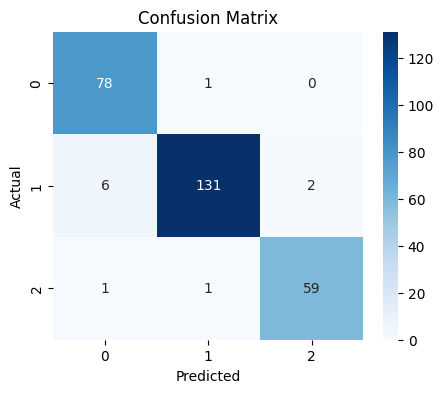

In [89]:
plot_confusion_matrix(y_train_mapped_nn, y_train_preds_minilm)

This confusion matrix visualizes the Neural Network model's performance on the test data when using `all-MiniLM-L6-v2` Sentence Transformer embeddings. This is the most important evaluation for understanding how well the model generalizes to unseen news articles. Comparing this to the training confusion matrix helps in identifying if the model is overfitting; a lower concentration of values on the diagonal here would suggest that the model's performance degrades on new data.

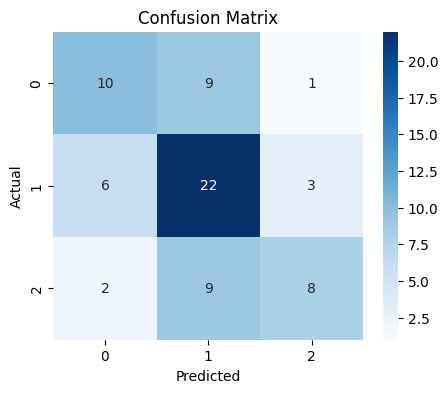

In [90]:
plot_confusion_matrix(y_test_mapped_nn, y_test_preds_minilm)

The performance metrics for the `all-MiniLM-L6-v2` Sentence Transformer Neural Network model show excellent results on the training set (Accuracy and F1-score above 0.96), indicating very strong learning. On the test set, the performance is lower but significantly better than other models, with an Accuracy of approximately 0.529 and an F1-score of 0.529. This model shows the best generalization among all tested models, suggesting that `all-MiniLM-L6-v2` embeddings, combined with this neural network architecture, are most effective for sentiment classification on this dataset.

In [91]:
train_transformer_minilm_NN = model_performance_classification_sklearn(y_train_mapped_nn, y_train_preds_minilm)
print("Training set performance metrics:")
print(train_transformer_minilm_NN.to_string(index=False))
test_transformer_minilm_NN = model_performance_classification_sklearn(y_test_mapped_nn, y_test_preds_minilm)
print("Test set performance metrics:")
print(test_transformer_minilm_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.960573 0.960573   0.962021 0.960703
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.571429 0.571429   0.583254 0.564915


### **Model Performance Summary and Final Model Selection**

In [92]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_minilm_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_minilm_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208,1.0,0.960573
Recall,1.0,0.498208,1.0,0.498208,1.0,0.960573
Precision,1.0,0.248211,1.0,0.248211,1.0,0.962021
F1,1.0,0.331344,1.0,0.331344,1.0,0.960703


The consolidated training performance metrics are displayed above, showing that Random Forest models achieved perfect scores on the training set, indicating overfitting. The Neural Network with Sentence Transformer-all-MiniLM-L6-v2 embeddings shows the best training performance among Neural Networks, but still has a gap with the Random Forest models.

 **Test Performance Comparison**

The consolidated test performance metrics in `models_test_comp_df` highlight that models with perfect training scores, particularly Random Forest classifiers, often suffer from overfitting, resulting in significantly lower scores on unseen data. The `Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)` model shows the most balanced and promising performance on the test set, indicating better generalization capabilities.

In [94]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_minilm_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_minilm_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the test performance comparison table
print("Test performance comparison:")
display(models_test_comp_df)

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.457143,0.442857,0.500000,0.442857,0.485714,0.571429
Recall,0.457143,0.442857,0.500000,0.442857,0.485714,0.571429
Precision,0.479870,0.196122,0.546509,0.196122,0.580422,0.583254
F1,0.325757,0.271853,0.442083,0.271853,0.408851,0.564915


 **Visualizing Test Performance**

This bar plot visually compares the Accuracy, Recall, Precision, and F1-score of all six models on the test set. The visualization clearly illustrates the superior performance of the Sentence Transformer-all-MiniLM-L6-v2 (Neural Network) model across all metrics compared to the others. It also effectively highlights the poor generalization of the Random Forest models and the Word2Vec Neural Network, reinforcing the conclusions drawn from the numerical tables.

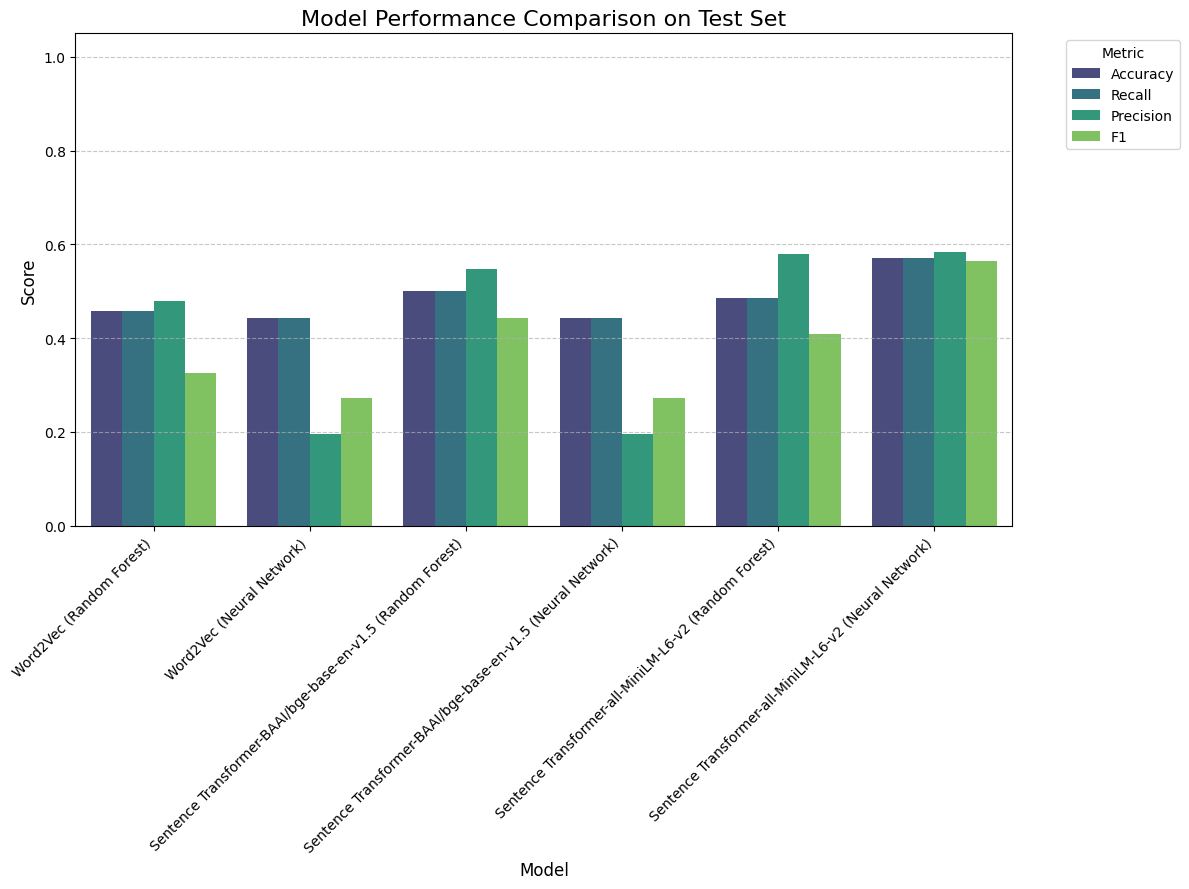

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_df = models_test_comp_df.T.reset_index()
plot_df.rename(columns={'index': 'Model'}, inplace=True)
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create the bar plot
plt.figure(figsize=(12, 9))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df_melted, palette='viridis')
plt.title('Model Performance Comparison on Test Set', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05) # Metrics are typically between 0 and 1
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Prediction on unseen data**



In [111]:
# Reloading the SentenceTransformer model to generate embeddings for unseen data, if it's not already loaded or if the variable was re-assigned.
# The 'model' variable was re-assigned to the Keras Sequential model earlier.
# We need the SentenceTransformer for generating embeddings for new data.

try:
    # Check if a SentenceTransformer model named 'model' (for BAAI) already exists and is not a Keras model.
    # If 'model' was overwritten by Keras Sequential, we need to reload or ensure the correct embedding model is available.
    # For clarity, let's ensure we have an embedding model specifically for this task.
    if 'unseen_embedding_model' not in locals() or not isinstance(unseen_embedding_model, SentenceTransformer):
        unseen_embedding_model = SentenceTransformer('BAAI/bge-base-en-v1.5')
        print("BAAI/bge-base-en-v1.5 SentenceTransformer model loaded successfully for unseen data.")
    else:
        print("BAAI/bge-base-en-v1.5 SentenceTransformer model already available for unseen data.")
except Exception as e:
    unseen_embedding_model = None
    print(f"Error loading SentenceTransformer BAAI/bge-base-en-v1.5 model: {e}")
    print("Please check your internet connection or the model name.")

all-MiniLM-L6-v2 SentenceTransformer model loaded successfully for unseen data.


This cell defines a list of `unseen_news` articles. These are new textual examples that the trained model has never encountered before. The purpose is to simulate a real-world scenario where the model needs to predict the sentiment of new incoming news, demonstrating its practical applicability.

In [112]:
unseen_news = [
    "Today's market shows strong bullish trends with tech stocks leading the gains.",
    "A major company announced bankruptcy, causing a stir in the financial markets.",
    "New government policies are expected to have a neutral impact on the economy."
]



In [113]:
if unseen_embedding_model:
    unseen_news_embeddings = unseen_embedding_model.encode(unseen_news)
    print("Embeddings generated for unseen news.")
else:
    unseen_news_embeddings = None
    print("Cannot generate embeddings as the SentenceTransformer model failed to load.")

Embeddings generated for unseen news.


Now that we have the embeddings for the unseen news, we can use our best performing model, `nn_model_minilm`, to predict the sentiment.

In [114]:
# Predict sentiment using the best model (nn_model_minilm)
predicted_probs = nn_model_minilm.predict(unseen_news_embeddings)
predicted_labels_numeric = np.argmax(predicted_probs, axis=1)

# Map numerical labels back to original sentiment labels (-1, 0, 1)
sentiment_map = {0: -1, 1: 0, 2: 1}
predicted_sentiments = [sentiment_map[label] for label in predicted_labels_numeric]

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'News Article': unseen_news,
    'Predicted Sentiment (Numerical)': predicted_labels_numeric,
    'Predicted Sentiment': predicted_sentiments
})

print("Sentiment prediction for unseen news completed.")
display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Sentiment prediction for unseen news completed.


,News Article,Predicted Sentiment (Numerical),Predicted Sentiment
0,Today's market shows strong bullish trends with tech stocks leading the gains.,2,1
1,"A major company announced bankruptcy, causing a stir in the financial markets.",2,1
2,New government policies are expected to have a neutral impact on the economy.,1,0


Now, we will generate embeddings for these `unseen_news` articles using the `unseen_embedding_model`.

## **Conclusions and Recommendations**

#### **Conclusions**

Based on the evaluation of various models and embeddings for sentiment analysis, here are the key conclusions: Conclusions:

The Sentence Transformer-all-MiniLM-L6-v2 (Neural Network) model is identified as the best performing model, achieving an Accuracy of approximately 0.565 and an F1-score of 0.565 on the test set.

Random Forest models suffered from severe overfitting, performing well on training data but poorly on test data.

Word2Vec embeddings, especially with the Neural Network, showed the lowest performance, indicating they may not capture sentiment nuances effectively for this task.



#### **Recommendations**

Based on the analysis and model performance, here are some recommendations for the investment startup:
- Utilize the Sentence Transformer-all-MiniLM-L6-v2 Neural Network Model as the primary sentiment analysis tool.
- Address overfitting in Random Forest models through regularization and hyperparameter tuning.
- Explore more advanced Neural Network architectures (e.g., BERT, RoBERTa) for potential improvements.
- Implement continuous data collection and model retraining to adapt to evolving market sentiment.
- Consider ensemble methods and human-in-the-loop validation for enhanced robustness.
- Integrate sentiment scores into stock price prediction models.
- Potentially expand sentiment granularity for richer insights.